In [1]:
from scipy.signal import savgol_filter
from RamanModel import *
from HelperFunctions import *
import numpy as np
import matplotlib.pyplot as plt

# Create an example spectrum

We create a single example of a spectrum

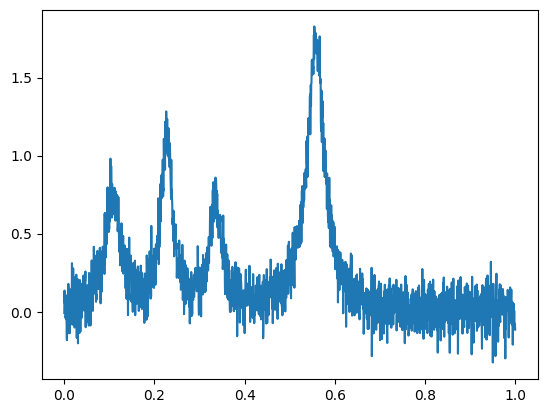

In [8]:
parameters = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.1, 1),
    "gamma_range": (0.001, 0.05),
    "x_min": 0,
    "x_max": 1
}

x = np.linspace(0, 1, 1876)
x, y, params = generateCurve(parameters, 4, len(x), noise_sigma=0.1)
plt.plot(x, y)

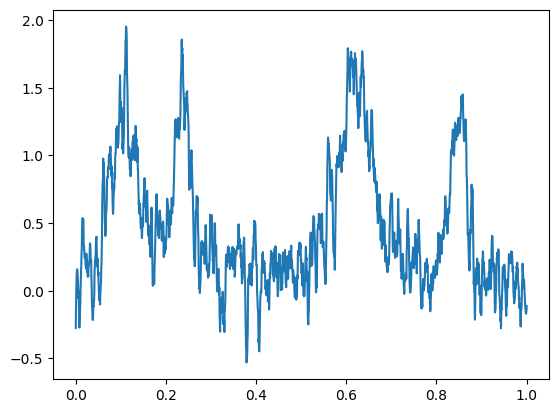

In [14]:
filtered = savgol_filter(y, window_length=21, polyorder=3)
plt.plot(x, filtered)


Generated Curve Parameters:
-------------------------------------------------------
Peak ID    | Center       | Amplitude    | Gamma       
-------------------------------------------------------
0          | 0.8483       | 0.7703       | 0.0159      
1          | 0.1100       | 0.7131       | 0.0286      
2          | 0.6232       | 0.7552       | 0.0490      
3          | 0.2370       | 0.6927       | 0.0204      
-------------------------------------------------------



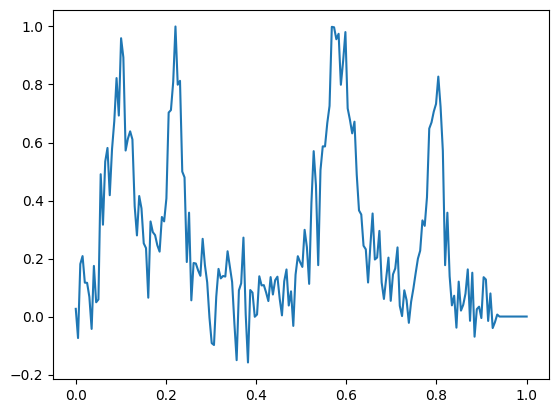

In [15]:
test = downsample_and_normalize(filtered, 200)
flattened_x = np.linspace(0, 1, 200)
plt.plot(flattened_x, test)
print_peak_params(params)

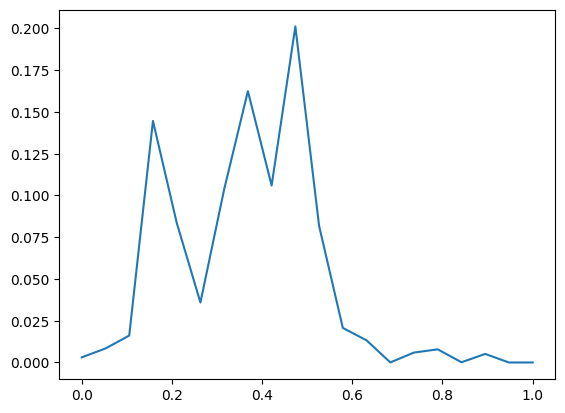

In [12]:
test2 = create_probability_map(y, num_peaks=4, resolution=20)
plt.plot(np.linspace(0,1,20), test2)

# Shifting Axes

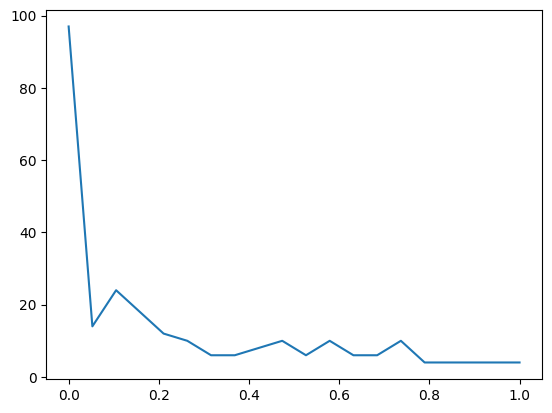

In [62]:
shifted = shift_axis(filtered,20)
plot_x = np.linspace(0,1,20)
plt.plot(plot_x, shifted)

# Run Simulated Annealing

Running simulated annealing to generate heatmap

In [3]:
energy, index, map = simulated_annealing(y, kmax=100, max_temp=0.5, cooling_factor=400, samples=100, num_repetitions=400)

Number of samples generated: 40000


In [10]:
flattened = flatten_SA_map(map, len(y), samples_per_pixel=20, function=log_transform)
#flattened = flatten_SA_map(map, len(y), samples_per_pixel=20)

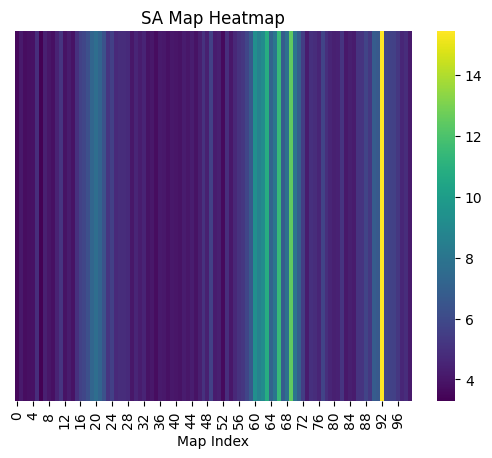

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(flattened.reshape(1, -1), cmap="viridis", cbar=True)

plt.title("SA Map Heatmap")
plt.xlabel("Map Index")
plt.yticks([])

plt.show()


Generated Curve Parameters:
-------------------------------------------------------
Peak ID    | Center       | Amplitude    | Gamma       
-------------------------------------------------------
0          | 0.9189       | 0.3105       | 0.0344      
1          | 0.2009       | 0.3877       | 0.0299      
2          | 0.6259       | 0.4187       | 0.0424      
3          | 0.6972       | 0.2980       | 0.0209      
-------------------------------------------------------



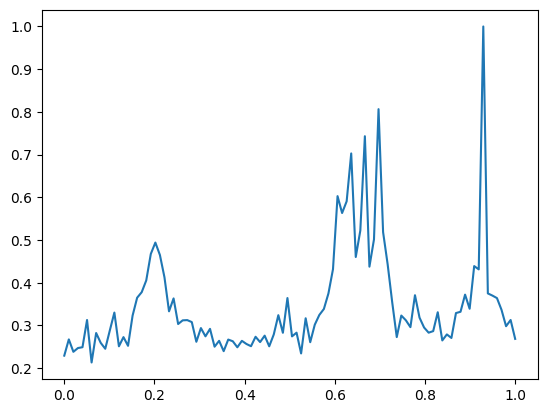

In [12]:
flattened_x = np.linspace(0, 1, (len(y)//20))
plt.plot(flattened_x, (flattened/max(flattened)))


In [13]:
# TODO: Test adding weight related to the temperature to makes these differences even more significant.

In [14]:
test = np.zeros(len(y)//20)
accum = 0
idx = 0
for i in range(1, len(y)+1):
    accum += y[i-1]
    if (i%20 == 0):
        test[idx] = accum/20
        accum = 0
        idx += 1 